In [1]:
import sys
import os
from dotenv import load_dotenv

In [9]:
load_dotenv()

print(f"Python version: {sys.version}")

packages = ['arc_agi', 'dotenv', 'requests', 'PIL', 'numpy']
for pkg in packages:
    try:
        __import__(pkg)
        print(f"{pkg} is installed.")
    except ImportError:
        print(f"{pkg} is NOT installed.")

api_key = os.getenv('ARC_API_KEY')
if api_key:
    print("API key is set.")
else:
    print("API key is NOT set. Please check your .env file.")



arc = arc_agi.Arcade(api_key=api_key)
print("Connected to ARC-AGI 3 successfully.")


print("Available games")
try:
    games = arc.list_games()
    print(f"Total games available: {len(games)}")
    print("\nFirst 5 games:")
    for game in games[:5]:
        print(f" -> {game}")
except Exception as e:
    print(f"Error fetching games: {e}")

Python version: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
arc_agi is installed.
dotenv is installed.
requests is installed.
PIL is installed.
numpy is installed.
API key is set.


TypeError: Arcade.__init__() got an unexpected keyword argument 'api_key'

In [4]:
import arc_agi
print(dir(arc_agi))

['APIError', 'Arcade', 'EnvironmentInfo', 'EnvironmentScore', 'EnvironmentScoreCalculator', 'EnvironmentScoreList', 'EnvironmentScorecard', 'EnvironmentWrapper', 'LocalEnvironmentWrapper', 'OperationMode', 'RemoteEnvironmentWrapper', 'RestAPI', 'ScorecardManager', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'api', 'base', 'local_wrapper', 'models', 'remote_wrapper', 'rendering', 'scorecard', 'wrapper']


In [10]:
import arc_agi
help(arc_agi.Arcade.__init__)

Help on function __init__ in module arc_agi.base:

__init__(
    self,
    arc_api_key: str = '',
    arc_base_url: str = 'https://three.arcprize.org',
    operation_mode: OperationMode = <OperationMode.NORMAL: 'normal'>,
    environments_dir: str = 'environment_files',
    recordings_dir: str = 'recordings',
    logger: Optional[logging.Logger] = None
) -> None
    Initialize ARCAGI3 instance.

    Args:
        arc_api_key: API key for ARC API. Defaults to empty string.
            Can be overridden by ARC_API_KEY environment variable.
        arc_base_url: Base URL for ARC API. Defaults to "https://three.arcprize.org".
            Can be overridden by ARC_BASE_URL environment variable.
        operation_mode: NORMAL (local + API), ONLINE (API only), or OFFLINE (local only).
            Defaults to NORMAL. Can be overridden by OPERATION_MODE env var
            ("normal", "online", "offline", "competition").
        environments_dir: Directory to scan for metadata.json files. Default

In [11]:
arc = arc_agi.Arcade()
print("Connected to ARC-AGI-3 successfully")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 15:52:49 | INFO | Successfully fetched 25 environment(s) from API
Connected to ARC-AGI-3 successfully


In [13]:
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=__import__('os').getenv("ARC_API_KEY"))

methods = [m for m in dir(arc) if not m.startswith('_')]
print("Available methods on Arcade:")
for m in methods:
    print(f"  → {m}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 15:54:24 | INFO | Successfully fetched 25 environment(s) from API
Available methods on Arcade:
  → arc_api_key
  → arc_base_url
  → available_environments
  → close_scorecard
  → create_scorecard
  → environments_dir
  → get_environments
  → get_scorecard
  → listen_and_serve
  → logger
  → make
  → on_scorecard_close
  → open_scorecard
  → operation_mode
  → recordings_dir
  → scorecard_manager


In [14]:
envs = arc.get_environments()
print(f"Total environments available: {len(envs)}")
print("\nEnvironments List:")
for env in envs:
    print(f"  → {env}")

print("First Environment Details:")
first = envs[0]
print(f"Type: {type(first)}")
print(f"Attributes: {[a for a in dir(first) if not a.startswith('_')]}")

Total environments available: 25

Environments List:
  → game_id='ka59-38d34dbb' title='KA59' default_fps=5 tags=['keyboard_click'] private_tags=None level_tags=None baseline_actions=[28, 109, 51, 51, 33, 132, 326] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864043, tzinfo=datetime.timezone.utc) class_name='Ka59' local_dir=None
  → game_id='g50t-5849a774' title='G50T' default_fps=5 tags=['keyboard'] private_tags=None level_tags=None baseline_actions=[78, 175, 179, 230, 96, 54, 67] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864073, tzinfo=datetime.timezone.utc) class_name='G50t' local_dir=None
  → game_id='dc22-fdcac232' title='DC22' default_fps=5 tags=['keyboard_click'] private_tags=None level_tags=None baseline_actions=[59, 102, 67, 98, 324, 578] date_downloaded=datetime.datetime(2026, 6, 12, 10, 24, 24, 864084, tzinfo=datetime.timezone.utc) class_name='Dc22' local_dir=None
  → game_id='sk48-d8078629' title='SK48' default_fps=5 tags=['keyboard_click'] pr

In [16]:
# LS20

target = None
for env in envs:
    if env.title == "LS20":
        target = env
        break

print(f"Selected environment: {target.title}")
print(f"Game ID: {target.game_id}")
print(f"Tags: {target.tags}")
print(f"Baseline actions per level: {target.baseline_actions}")
print(f"Total levels: {len(target.baseline_actions)}")

print("\nOpening Scorecard")
try:
    scorecard = arc.open_scorecard(game_id=target.game_id)
    print(f"Scorecard opened!")
    print(f"Scorecard attributes: {[a for a in dir(scorecard) if not a.startswith('_')]}")
except Exception as e:
    print(f"Error: {e}")
    # Try with make instead
    print("\nTrying arc.make()...")
    env_instance = arc.make(target.game_id)
    print(f"Environment created!")
    print(f"Type: {type(env_instance)}")
    print(f"Attributes: {[a for a in dir(env_instance) if not a.startswith('_')]}")

Selected environment: LS20
Game ID: ls20-9607627b
Tags: ['keyboard']
Baseline actions per level: [22, 123, 73, 84, 96, 192, 186]
Total levels: 7

Opening Scorecard
Error: Arcade.open_scorecard() got an unexpected keyword argument 'game_id'

Trying arc.make()...
2026-06-12 16:00:40 | INFO | Created new scorecard: 858b5bbd-0ea8-4305-a453-49ec90aa8c8b
2026-06-12 16:00:44 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:00:50 | INFO | Successfully downloaded game ls20 (version: 9607627b) to environment_files\ls20\9607627b
2026-06-12 16:00:50 | INFO | Successfully loaded game class Ls20 from environment_files\ls20\9607627b\ls20.py
Environment created!
Type: <class 'arc_agi.local_wrapper.LocalEnvironmentWrapper'>
Attributes: ['action_space', 'environment_info', 'include_frame_data', 'info', 'logger', 'observation_space', 'recordings_dir', 'renderer', 'reset', 'save_recording', 'scorecard_id', 'scorecard_manager', 'step']


In [17]:
env_instance = arc.make(target.game_id)

print("Action Space")
print(type(env_instance.action_space))
print(env_instance.action_space)

print("\nObservation Space")
print(type(env_instance.observation_space))
print(env_instance.observation_space)

print("\nResetting Environment")
obs = env_instance.reset()
print(type(obs))
print(obs)

print("\nEnvironment Info")
info = env_instance.info
print(type(info))
print(info)

2026-06-12 16:02:22 | INFO | Successfully fetched metadata for game ls20
Action Space
<class 'list'>
[<GameAction.ACTION1: 1>, <GameAction.ACTION2: 2>, <GameAction.ACTION3: 3>, <GameAction.ACTION4: 4>]

Observation Space
<class 'arcengine.enums.FrameDataRaw'>
{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 0,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": true,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}

Resetting Environment
<class 'arcengine.enums.FrameDataRaw'>
{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 0,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": true,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}

Environment Info
<class 'arc_agi.models.EnvironmentInfo'>
g

In [19]:
import json

obs = env_instance.reset()

obs_dict = json.loads(obs.json()) if hasattr(obs, 'json') else obs.__dict__

print("Full observation keys:")
for key in obs_dict.keys():
    value = obs_dict[key]
    print(f"  {key}: {type(value).__name__} = {str(value)[:100]}")

print("\nTaking one action and observing result")
result = env_instance.step(1)
print(f"Result type: {type(result)}")
print(f"Result: {str(result)[:500]}")

Full observation keys:
  game_id: str = ls20-9607627b
  state: str = NOT_FINISHED
  levels_completed: int = 0
  win_levels: int = 7
  action_input: dict = {'id': 0, 'data': {}, 'reasoning': None}
  guid: str = 0f2f13df-7ba9-41e9-bb0f-b7661500fad2
  full_reset: bool = True
  available_actions: list = [1, 2, 3, 4]

Taking one action and observing result
Result type: <class 'arcengine.enums.FrameDataRaw'>
Result: {
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 1,
    "data": {},
    "reasoning": null
  },
  "guid": "0f2f13df-7ba9-41e9-bb0f-b7661500fad2",
  "full_reset": false,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


C:\Users\Subramani Mokkala\AppData\Local\Temp\ipykernel_25056\2264196043.py:5: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  obs_dict = json.loads(obs.json()) if hasattr(obs, 'json') else obs.__dict__


In [20]:
obs = env_instance.reset()

print("obs type:", type(obs))
print("has frame_data:", hasattr(obs, 'frame_data'))
print("has image:", hasattr(obs, 'image'))
print("has pixels:", hasattr(obs, 'pixels'))
print("has data:", hasattr(obs, 'data'))

print("\nAll attributes and values:")
for key, value in obs:
    print(f"  {key} ({type(value).__name__}): {str(value)[:200]}")

print("\nenv_instance.include_frame_data:", env_instance.include_frame_data)

obs type: <class 'arcengine.enums.FrameDataRaw'>
has frame_data: False
has image: False
has pixels: False
has data: False

All attributes and values:
  game_id (str): ls20-9607627b
  state (GameState): GameState.NOT_FINISHED
  levels_completed (int): 0
  win_levels (int): 7
  action_input (ActionInput): id=<GameAction.RESET: 0> data={} reasoning=None
  guid (str): 0f2f13df-7ba9-41e9-bb0f-b7661500fad2
  full_reset (bool): False
  available_actions (list): [1, 2, 3, 4]

env_instance.include_frame_data: True


In [21]:
import arc_agi
help(arc_agi.Arcade.make)

Help on function make in module arc_agi.base:

make(
    self,
    game_id: str,
    seed: int = 0,
    scorecard_id: Optional[str] = None,
    save_recording: bool = False,
    include_frame_data: bool = True,
    render_mode: Optional[str] = None,
    renderer: Optional[Callable[[int, FrameDataRaw], None]] = None
) -> Optional[EnvironmentWrapper]
    Make (download and prepare) an environment.

    Args:
        game_id: Game identifier in format 'ls20' or 'ls20-1234abcd'.
            The first 4 characters are the game_id, everything after '-' is the version.
        scorecard_id: Optional scorecard ID for tracking runs. If not provided,
            a new scorecard will be created and stored for subsequent calls.
        save_recording: Whether to save recordings to JSONL file.
        render_mode: Optional render mode string ("human", "terminal"). If provided,
            creates a renderer callable automatically.
        renderer: Optional callable that accepts FrameDataRaw and pe

In [22]:
import os
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))

env_instance = arc.make(
    game_id="ls20",
    render_mode="terminal",
    save_recording=True
)

obs = env_instance.reset()

print("state:", obs.state)
print("levels_completed:", obs.levels_completed)
print("win_levels:", obs.win_levels)
print("available_actions:", obs.available_actions)

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 16:06:18 | INFO | Successfully fetched 25 environment(s) from API
2026-06-12 16:06:18 | INFO | Created new scorecard: 4778e0c1-7247-4f52-ade8-6d53761ec8e2
2026-06-12 16:06:19 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:06:19 | INFO | Recording to recordings\4778e0c1-7247-4f52-ade8-6d53761ec8e2\ls20-9607627b-97b1aee3-1778-4fc4-9d2e-38ef8163c749.jsonl
Step: 1 - State: NOT_FINISHED

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████████████

Step: 2 - State: NOT_FINISHED

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
██████████████████████████████████████████████████████████████████

state: GameState.NOT_FINISHED
levels_completed: 0
win_levels: 7
available_actions: [1, 2, 3, 4]


In [23]:
import os
import random
import arc_agi
from dotenv import load_dotenv
load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))

env = arc.make(
    game_id="ls20",
    save_recording=True
)

obs = env.reset()

step = 0
max_steps = 500

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    action = random.choice(obs.available_actions)
    obs = env.step(action)
    step += 1

    if step % 50 == 0:
        print(f"step {step} | state: {obs.state.value} | levels completed: {obs.levels_completed}")

print(f"\nGame ended after {step} steps")
print(f"Final state: {obs.state.value}")
print(f"Levels completed: {obs.levels_completed} / {obs.win_levels}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-12 16:07:15 | INFO | Successfully fetched 25 environment(s) from API
2026-06-12 16:07:15 | INFO | Created new scorecard: 484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806
2026-06-12 16:07:17 | INFO | Successfully fetched metadata for game ls20
2026-06-12 16:07:17 | INFO | Recording to recordings\484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806\ls20-9607627b-86c3c1d7-4ad4-45f6-bb12-e21be3a54e64.jsonl
step 50 | state: NOT_FINISHED | levels completed: 0
step 100 | state: NOT_FINISHED | levels completed: 0

Game ended after 137 steps
Final state: GAME_OVER
Levels completed: 0 / 7


In [24]:
import json
import os

recordings_dir = "recordings"
all_files = []
for root, dirs, files in os.walk(recordings_dir):
    for file in files:
        if file.endswith(".jsonl"):
            all_files.append(os.path.join(root, file))

latest = sorted(all_files)[-1]
print(f"Reading: {latest}")

frames = []
with open(latest, "r") as f:
    for line in f:
        frames.append(json.loads(line))

print(f"Total frames recorded: {len(frames)}")
print(f"\nFirst frame keys: {list(frames[0].keys())}")
print(f"\nFirst frame:")
print(json.dumps(frames[0], indent=2)[:1000])

Reading: recordings\484bb3d7-8e2d-4f2f-a4c2-33c34b4ea806\ls20-9607627b-86c3c1d7-4ad4-45f6-bb12-e21be3a54e64.jsonl
Total frames recorded: 139

First frame keys: ['timestamp', 'data']

First frame:
{
  "timestamp": "2026-06-12T10:37:17.251959+00:00",
  "data": {
    "game_id": "ls20-9607627b",
    "state": "NOT_FINISHED",
    "levels_completed": 0,
    "win_levels": 7,
    "action_input": {
      "id": "RESET",
      "data": {},
      "reasoning": null
    },
    "guid": "86c3c1d7-4ad4-45f6-bb12-e21be3a54e64",
    "full_reset": true,
    "available_actions": [
      1,
      2,
      3,
      4
    ],
    "frame": [
      [
        [
          5,
          5,
          5,
          5,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
          4,
         

Frame shape after squeeze: (64, 64)
Unique color values: [0, 1, 3, 4, 5, 8, 9, 11, 12]


FileNotFoundError: [Errno 2] No such file or directory: 'logs/ls20_first_last_frame.png'

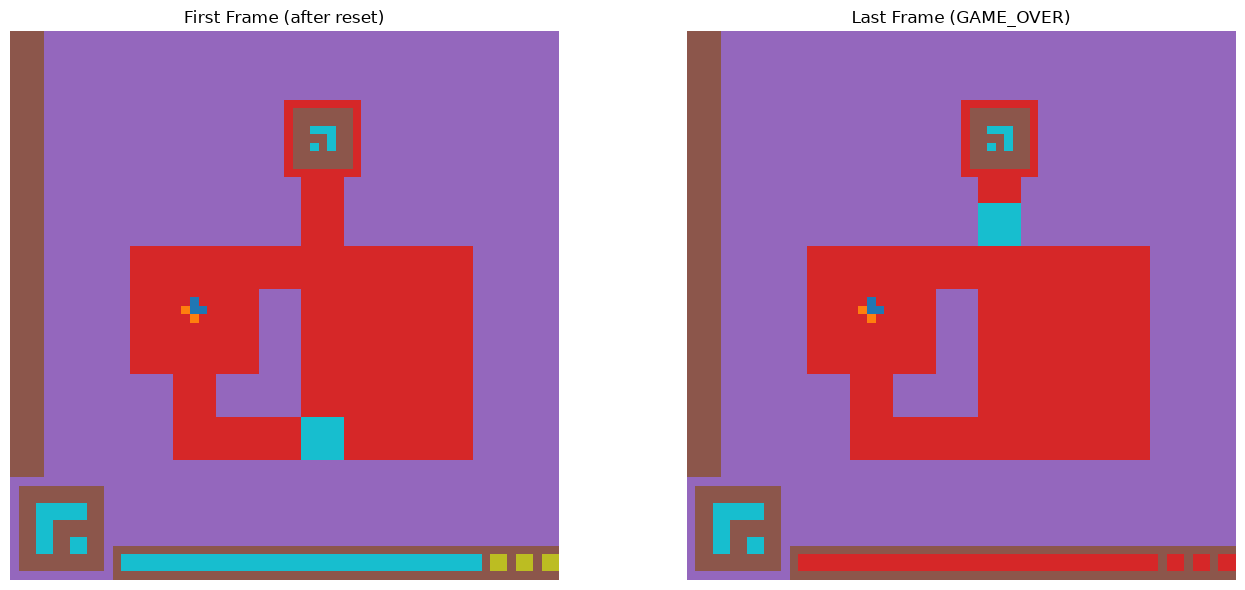

In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(latest, "r") as f:
    frames = [json.loads(line) for line in f]

first_frame = np.array(frames[0]["data"]["frame"]).squeeze()
last_frame = np.array(frames[-1]["data"]["frame"]).squeeze()

print(f"Frame shape after squeeze: {first_frame.shape}")
print(f"Unique color values: {np.unique(first_frame).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(first_frame, cmap="tab10", vmin=0, vmax=9)
axes[0].set_title("First Frame (after reset)")
axes[0].axis("off")

axes[1].imshow(last_frame, cmap="tab10", vmin=0, vmax=9)
axes[1].set_title("Last Frame (GAME_OVER)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("logs/ls20_first_last_frame.png", dpi=100)
plt.show()

In [ ]:
import os

os.makedirs("logs", exist_ok=True)
plt.savefig("logs/ls20_first_last_frame.png", dpi=100)
print("saved to logs/ls20_first_last_frame.png")

saved to logs/ls20_first_last_frame.png


<Figure size 640x480 with 0 Axes>